In [1]:
import edn_popdyn.paths
from edn_popdyn.paths import (
    DATA_ROOT, PCA_ROOT, FIGURES_DIR, STATS_CSV_DIR,
)

In [2]:
from edn_popdyn import colors as pal

# 2.1 — Population latent decoding

Projects each population's smoothed spike train into a low-dimensional PCA latent
space and decodes stimulus identity from the single-trial trajectory.

## 0) Imports and config

In [3]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "2")

import sys
import glob
import pickle
import types
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm.autonotebook import tqdm
from scipy.stats import ttest_1samp, wilcoxon

from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from joblib import Parallel, delayed

_numeric_mod = types.ModuleType("pandas.core.indexes.numeric")
_numeric_mod.Int64Index = pd.Index
_numeric_mod.Float64Index = pd.Index
_numeric_mod.UInt64Index = pd.Index
sys.modules["pandas.core.indexes.numeric"] = _numeric_mod

/tmp/ipykernel_2642419/4279626601.py:17: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [4]:
import sys, importlib, importlib.abc, importlib.machinery

class _NumpyCoreRedirect(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    PREFIX = "numpy._core"

    def find_spec(self, fullname, path=None, target=None):
        if fullname == self.PREFIX or fullname.startswith(self.PREFIX + "."):
            return importlib.machinery.ModuleSpec(fullname, self)
        return None

    def create_module(self, spec):
        mod = importlib.import_module("numpy.core" + spec.name[len(self.PREFIX):])
        sys.modules[spec.name] = mod
        return mod

    def exec_module(self, module):
        pass

try:
    import numpy._core
    print("numpy._core present; no shim needed (numpy %s)" % __import__("numpy").__version__)
except ModuleNotFoundError:
    if not any(isinstance(f, _NumpyCoreRedirect) for f in sys.meta_path):
        sys.meta_path.insert(0, _NumpyCoreRedirect())
    import numpy.core
    print("Installed numpy._core -> numpy.core redirect (numpy %s)"
          % __import__("numpy").__version__)

numpy._core present; no shim needed (numpy 2.2.6)


In [5]:
AREA     = 'ALL'
BASE_DIR = Path(f"{DATA_ROOT}/{AREA}")
DATA_DIR = BASE_DIR

In [6]:
statistics_timestamp = None

PCA_BASE_TEMPLATE = str(PCA_ROOT)

INC_CSV = f"{DATA_ROOT}/included_sessions.csv"
USE_INCLUSION_LIST = True

OUT_DIR   = f"{FIGURES_DIR}/decoding"
STATS_DIR = f"{STATS_CSV_DIR}/decoding"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(STATS_DIR, exist_ok=True)

STRENGTHS = ("sL", "wL", "wR", "sR")

DECODER          = "lda"

N_FOLDS          = 5
N_REPEATS        = 3
N_PERM           = 200
MIN_TRIALS_CLASS = N_FOLDS
RANDOM_STATE     = 0
N_JOBS           = 20

DECODE_TIME_RESOLVED = False
N_REPEATS_TR         = 1
TIME_STRIDE          = 2

FILTER_CONTEXT  = None
FILTER_VALIDITY = None
FILTER_OUTCOME  = None

RESP_WINDOW = None

rng = np.random.default_rng(RANDOM_STATE)
print(f"AREA={AREA}  decoder={DECODER}  folds={N_FOLDS}x{N_REPEATS}  perms={N_PERM}")

AREA=ALL  decoder=lda  folds=5x3  perms=200


## 1) Session discovery and latent loading

In [7]:
def discover_statistics_timestamp(data_dir):
    stat_dir = Path(data_dir) / "unit_statistics"
    if not stat_dir.exists():
        print(f"  [warn] No unit_statistics dir: {stat_dir}")
        return None
    timestamps = sorted([d.name for d in stat_dir.iterdir() if d.is_dir()])
    if not timestamps:
        print(f"  [warn] No timestamp subdirs in {stat_dir}")
        return None
    ts = timestamps[-1]
    print(f"  Auto-detected statistics_timestamp = {ts!r}")
    return ts

def discover_pca_sessions(area):
    pca_base  = PCA_BASE_TEMPLATE.format(area=area)
    pca_paths = sorted(glob.glob(os.path.join(pca_base, '*', '*', 'trial_type_dict_pca.pkl')))
    sessions  = []
    for path in pca_paths:
        rec_dir   = os.path.dirname(path)
        bird      = os.path.basename(os.path.dirname(rec_dir))
        rec       = os.path.basename(rec_dir)
        timestamp = rec.split('dat', 1)[1] if 'dat' in rec else rec
        sessions.append((bird, timestamp))
    print(f"Found {len(sessions)} PCA sessions for area={area!r}")
    return sessions

In [8]:
pca_sessions = discover_pca_sessions(AREA)
birds = [(bird, ts) for bird, ts in pca_sessions]

if statistics_timestamp is None:
    statistics_timestamp = discover_statistics_timestamp(DATA_DIR)

if USE_INCLUSION_LIST and os.path.exists(INC_CSV):
    _inc = pd.read_csv(INC_CSV, dtype={"timestamp": str})
    inc_set = set(zip(_inc["bird"], _inc["timestamp"]))
    _b0 = len(birds)
    birds = [b for b in birds if (b[0], b[1]) in inc_set]
    print(f"Inclusion list applied: {_b0} -> {len(birds)} sessions")
else:
    print(f"No inclusion list applied ({len(birds)} sessions)")

print(f"{len(set(b for b, _ in birds))} birds: {sorted(set(b for b, _ in birds))}")

Found 344 PCA sessions for area='ALL'
  Auto-detected statistics_timestamp = '2021-10-23_23-02-31_846685'
Inclusion list applied: 344 -> 249 sessions
9 birds: ['B1170', 'B1188', 'B1244', 'B1248', 'B1276', 'B1426', 'B1432', 'B1593', 'B1595']


In [9]:
pca_base = PCA_BASE_TEMPLATE.format(area=AREA)
all_trial_dicts = {}
for bird, timestamp in tqdm(birds, desc="loading PCA latents"):
    rec  = f"exp1_rec1_dat{timestamp}"
    path = os.path.join(pca_base, bird, rec, 'trial_type_dict_pca.pkl')
    if not os.path.exists(path):
        continue
    with open(path, 'rb') as fh:
        all_trial_dicts[f'{bird}/{rec}'] = pickle.load(fh)
print(f"Loaded {len(all_trial_dicts)} sessions into all_trial_dicts")

session_bird = {name: name.split('/')[0] for name in all_trial_dicts}

loading PCA latents:   0%|          | 0/249 [00:00<?, ?it/s]

Loaded 239 sessions into all_trial_dicts


## 2) Condition-key parser and single-trial dataset builder

Condition keys follow `{strength}_{interp}_Z_{validity}_{outcome}_{context}`,
e.g. `sL_AE_Z_NC_correct_active`. Token 0 is the **strength** (position on the
continuum) and token 1 is the **interp** (which continuum - the ~9 morph spectra,
`AE`, `AF`, ...). 

In [10]:
def parse_key(key):

    p = key.split('_')
    if len(p) < 2:
        return None
    strength = p[0]
    interp   = p[1]

    validity = ('invalid' if 'invalid' in p else
                'valid'   if 'valid'   in p else
                'NC'      if 'NC'      in p else None)
    outcome  = ('incorrect' if 'incorrect' in p else
                'correct'   if 'correct'   in p else None)
    context  = ('active'  if 'active'  in p else
                'passive' if 'passive' in p else None)
    return dict(strength=strength, interp=interp,
                validity=validity, outcome=outcome, context=context)

def build_session_dataset(trial_dict, strengths=STRENGTHS,
                          filter_context=FILTER_CONTEXT,
                          filter_validity=FILTER_VALIDITY,
                          filter_outcome=FILTER_OUTCOME):

    Xs, y_str, y_int = [], [], []
    for key, x in trial_dict.items():
        meta = parse_key(key)
        if meta is None or meta['strength'] not in strengths:
            continue
        if filter_context  is not None and meta['context']  != filter_context:  continue
        if filter_validity is not None and meta['validity'] != filter_validity: continue
        if filter_outcome  is not None and meta['outcome']  != filter_outcome:  continue
        x = np.asarray(x, dtype=float)
        if x.ndim != 3 or x.shape[0] == 0:
            continue
        Xs.append(x)
        y_str.extend([meta['strength']] * x.shape[0])
        y_int.extend([meta['interp']]   * x.shape[0])
    if not Xs:
        return None

    n_t = min(a.shape[1] for a in Xs)
    n_c = min(a.shape[2] for a in Xs)
    Xs  = [a[:, :n_t, :n_c] for a in Xs]
    X   = np.concatenate(Xs, axis=0)
    stim_id = np.char.add(np.char.add(np.array(y_str).astype(str), "_"),
                          np.array(y_int).astype(str))
    return dict(X=X, strength=np.array(y_str), interp=np.array(y_int),
                stim_id=stim_id, n_time=n_t, n_comp=n_c)

In [11]:
datasets = {}
for name, td in tqdm(all_trial_dicts.items(), desc="building datasets"):
    ds = build_session_dataset(td)
    if ds is not None and ds['X'].shape[0] >= 2 * N_FOLDS:
        datasets[name] = ds

all_interps   = sorted({i for d in datasets.values() for i in np.unique(d['interp'])})
all_strengths = sorted({s for d in datasets.values() for s in np.unique(d['strength'])})
example_comps = {d['n_comp'] for d in datasets.values()}
example_time  = {d['n_time'] for d in datasets.values()}

print(f"Usable sessions: {len(datasets)}")
print(f"Strength classes ({len(all_strengths)}): {all_strengths}")
print(f"Interp continua  ({len(all_interps)}): {all_interps}")
print(f"n_comp across sessions: {sorted(example_comps)}")
print(f"n_time across sessions: {sorted(example_time)}")

building datasets:   0%|          | 0/239 [00:00<?, ?it/s]

Usable sessions: 239
Strength classes (4): [np.str_('sL'), np.str_('sR'), np.str_('wL'), np.str_('wR')]
Interp continua  (16): [np.str_('AE'), np.str_('AF'), np.str_('AG'), np.str_('AH'), np.str_('BE'), np.str_('BF'), np.str_('BG'), np.str_('BH'), np.str_('CE'), np.str_('CF'), np.str_('CG'), np.str_('CH'), np.str_('DE'), np.str_('DF'), np.str_('DG'), np.str_('DH')]
n_comp across sessions: [9]
n_time across sessions: [60]


## 3) vizualize smooth trajectories

Example session: B1432/exp1_rec1_dat2021-03-14_09-36-46_2000  (118 condition trajectories)


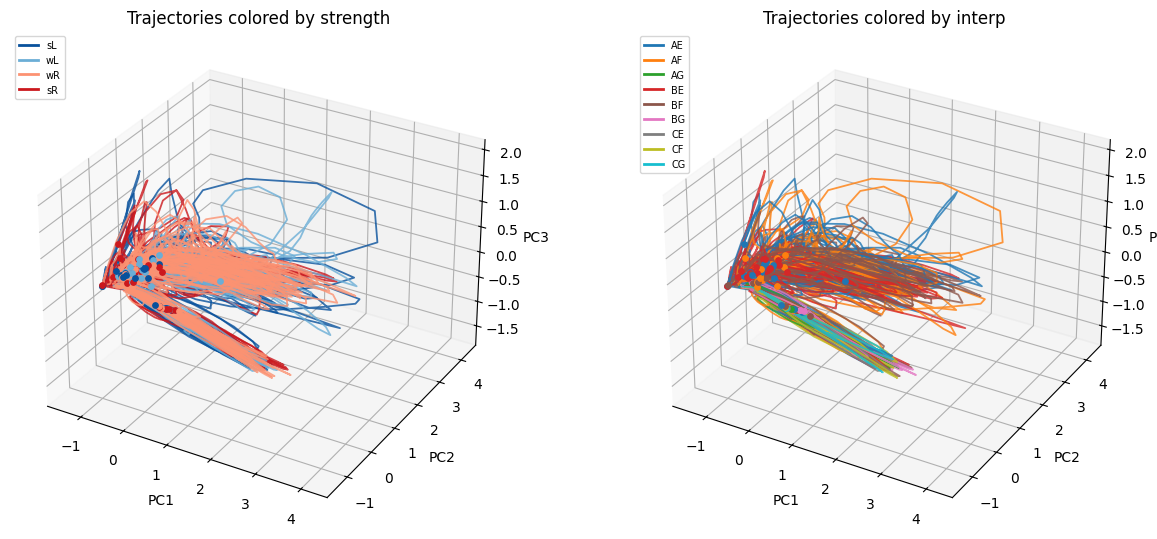

In [12]:
def condition_templates(trial_dict, strengths=STRENGTHS):

    out = []
    for key, x in trial_dict.items():
        meta = parse_key(key)
        if meta is None or meta['strength'] not in strengths:
            continue
        x = np.asarray(x, dtype=float)
        if x.ndim != 3 or x.shape[0] < 1:
            continue
        out.append((meta, np.nanmean(x, axis=0)))
    return out

example_session = max(datasets, key=lambda n: datasets[n]['X'].shape[0])
templates = condition_templates(all_trial_dicts[example_session])
print(f"Example session: {example_session}  ({len(templates)} condition trajectories)")

strength_colors = dict(zip(STRENGTHS, [pal.strength[0], pal.strength[1], pal.strength[2], pal.strength[3]]))
interp_list  = sorted({m['interp'] for m, _ in templates})
interp_cmap  = plt.cm.tab10(np.linspace(0, 1, max(len(interp_list), 1)))
interp_colors = {it: interp_cmap[i] for i, it in enumerate(interp_list)}

fig = plt.figure(figsize=(13, 5.5))
for col, (label_by, cmap) in enumerate([('strength', strength_colors),
                                        ('interp', interp_colors)]):
    ax = fig.add_subplot(1, 2, col + 1, projection='3d')
    for meta, traj in templates:
        c = cmap.get(meta[label_by], '0.5')
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=c, lw=1.3, alpha=0.8)
        ax.scatter(traj[0, 0], traj[0, 1], traj[0, 2], color=c, s=15)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title(f'Trajectories colored by {label_by}')
    handles = [plt.Line2D([0], [0], color=cmap[k], lw=2) for k in cmap]
    ax.legend(handles, list(cmap.keys()), fontsize=7, loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f"{AREA}_example_trajectories.svg"))
plt.show()

## 4) Decoding stimulus identity (continuum and bin)

In [13]:
def make_decoder():
    if DECODER == 'lda':
        clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    else:
        clf = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', n_jobs=1)
    return make_pipeline(StandardScaler(), clf)

def _can_cv(y, n_folds=N_FOLDS):
    classes, counts = np.unique(y, return_counts=True)
    return (len(classes) >= 2) and (counts.min() >= n_folds)

def _clean(X2d):

    return np.nan_to_num(np.asarray(X2d, dtype=float), nan=0.0, posinf=0.0, neginf=0.0)

def _fold_score(Xt, y, tr, te):
    try:
        clf = make_decoder()
        clf.fit(Xt[tr], y[tr])
        return balanced_accuracy_score(y[te], clf.predict(Xt[te]))
    except Exception:
        return np.nan

def cv_balanced_accuracy(Xt, y, n_folds=N_FOLDS, n_repeats=N_REPEATS,
                         seed=RANDOM_STATE, n_jobs=N_JOBS):

    if not _can_cv(y, n_folds):
        return np.nan
    Xt = _clean(Xt)
    splits = []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_folds, shuffle=True, random_state=seed + r)
        splits.extend(list(skf.split(Xt, y)))
    if n_jobs and n_jobs != 1:
        accs = Parallel(n_jobs=n_jobs, prefer="threads")(
            delayed(_fold_score)(Xt, y, tr, te) for tr, te in splits)
    else:
        accs = [_fold_score(Xt, y, tr, te) for tr, te in splits]
    accs = np.asarray(accs, dtype=float)
    return float(np.nanmean(accs)) if np.isfinite(accs).any() else np.nan

def decode_window(X, y, window=RESP_WINDOW):

    Xt = (np.nanmean(X, axis=1) if window is None
          else np.nanmean(X[:, window[0]:window[1], :], axis=1))
    return cv_balanced_accuracy(Xt, y)

def decode_window_perm(X, y, window=RESP_WINDOW, n_perm=N_PERM, seed=RANDOM_STATE):

    obs = decode_window(X, y, window)
    if not np.isfinite(obs):
        return obs, np.array([]), np.nan
    Xt = (np.nanmean(X, axis=1) if window is None
          else np.nanmean(X[:, window[0]:window[1], :], axis=1))
    rg = np.random.default_rng(seed)
    null = np.array([cv_balanced_accuracy(Xt, rg.permutation(y), n_repeats=1)
                     for _ in range(n_perm)])
    null = null[np.isfinite(null)]
    p = (1 + np.sum(null >= obs)) / (1 + len(null)) if len(null) else np.nan
    return obs, null, p

def decode_timeresolved(X, y, n_folds=N_FOLDS, n_repeats=N_REPEATS_TR,
                        seed=RANDOM_STATE, stride=TIME_STRIDE):

    n_t = X.shape[1]
    acc = np.full(n_t, np.nan)
    if not _can_cv(y, n_folds):
        return acc
    for t in range(0, n_t, max(stride, 1)):
        acc[t] = cv_balanced_accuracy(X[:, t, :], y, n_folds, n_repeats, seed)
    valid = np.isfinite(acc)
    if valid.sum() >= 2:
        idx = np.arange(n_t)
        acc = np.interp(idx, idx[valid], acc[valid])
    return acc


def keep_dense_classes(X, y, n_folds=N_FOLDS):
    classes, counts = np.unique(y, return_counts=True)
    keep = np.isin(y, classes[counts >= n_folds])
    return X[keep], np.asarray(y)[keep]

In [14]:
# Stimulus decoding: continuum identity (interp, 9-way) and bin (strength, 4-way

def decode_target(target):
    rows = []
    for name, ds in tqdm(datasets.items(), desc=f"decode {target}"):
        X, y = keep_dense_classes(ds['X'], ds[target])   # drop classes < N_FOLDS trials
        if not _can_cv(y):
            continue
        obs, null, _ = decode_window_perm(X, y)          # window-avg CV acc + perm null
        chance = float(np.nanmean(null)) if len(null) else np.nan
        rows.append(dict(session=name, bird=session_bird[name],
                         n_classes=int(len(np.unique(y))),
                         cv_acc=obs, perm_chance=chance, delta=obs - chance))
    return pd.DataFrame(rows)

def lme_above_chance(df, label):
    d = df.dropna(subset=["cv_acc", "perm_chance"])
    m = smf.mixedlm("delta ~ 1", d, groups=d["bird"]).fit(reml=True)
    b = m.params["Intercept"]; lo, hi = m.conf_int().loc["Intercept"]; p = m.pvalues["Intercept"]
    print(f"{label}: \u0394 balanced accuracy above chance = {b:+.3f}, "
          f"95% CI [{lo:+.3f}, {hi:+.3f}], p = {p:.2g}  "
          f"(n = {len(d)} populations, {d['bird'].nunique()} subjects)")

continuum_df = decode_target('interp')     # which of the 9 continua

decode interp:   0%|          | 0/239 [00:00<?, ?it/s]

In [15]:
bin_df       = decode_target('strength')   # which of the 4 bins

decode strength:   0%|          | 0/239 [00:00<?, ?it/s]

In [16]:
for _name, _df in [("continuum", continuum_df), ("bin", bin_df)]:
    _df.to_csv(os.path.join(STATS_DIR, f"{AREA}_decode_{_name}_per_session.csv"), index=False)

In [17]:
print()
lme_above_chance(continuum_df, "Continuum identity (9-way)")
lme_above_chance(bin_df,       "Bin along continuum (4-way)")


Continuum identity (9-way): Δ balanced accuracy above chance = +0.130, 95% CI [+0.089, +0.170], p = 3.8e-10  (n = 231 populations, 9 subjects)
Bin along continuum (4-way): Δ balanced accuracy above chance = +0.115, 95% CI [+0.085, +0.145], p = 7.9e-14  (n = 238 populations, 9 subjects)


/home/AD/jugorman/miniconda3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/AD/jugorman/miniconda3/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
